In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_216.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_98.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_137.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_86_1.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_19_1.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_202.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_159.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_217.mp4
/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet/non shop lifters/shop_lifter_n_185_1.mp4
/kaggle/input/datasets/me

# # BLOCK 1: EDA 

## 1. Setup paths

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = "/kaggle/input/datasets/mennathabett/shoplifting-dataset/Shop DataSet"

CLASS_DIRS = {
    "shop lifters": os.path.join(DATA_DIR, "shop lifters"),
    "non shop lifters": os.path.join(DATA_DIR, "non shop lifters"),
}

# ---- 2. Collect video file paths per class ----

In [3]:
video_records = []

for label, folder in CLASS_DIRS.items():
    if not os.path.isdir(folder):
        print(f"WARNING: folder not found -> {folder}")
        continue
    for fname in os.listdir(folder):
        if fname.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            video_records.append({
                "filepath": os.path.join(folder, fname),
                "filename": fname,
                "label": label
            })

df = pd.DataFrame(video_records)
print(f"Total videos found: {len(df)}")
print(df["label"].value_counts())

Total videos found: 855
label
non shop lifters    531
shop lifters        324
Name: count, dtype: int64


# ---- 3. Extract video metadata: frame count, fps, duration, resolution ----

In [4]:
def get_video_metadata(filepath):
    cap = cv2.VideoCapture(filepath)
    if not cap.isOpened():
        return None
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps > 0 else 0
    cap.release()
    return {
        "frame_count": frame_count,
        "fps": fps,
        "width": width,
        "height": height,
        "duration_sec": duration
    }

metadata = []
for i, row in df.iterrows():
    meta = get_video_metadata(row["filepath"])
    if meta:
        meta.update({"filename": row["filename"], "label": row["label"]})
        metadata.append(meta)
    if i % 50 == 0:
        print(f"Processed {i}/{len(df)}")

meta_df = pd.DataFrame(metadata)
meta_df.to_csv("video_metadata.csv", index=False)
meta_df.head()

Processed 0/855
Processed 50/855
Processed 100/855
Processed 150/855
Processed 200/855
Processed 250/855
Processed 300/855
Processed 350/855
Processed 400/855
Processed 450/855
Processed 500/855
Processed 550/855
Processed 600/855
Processed 650/855
Processed 700/855
Processed 750/855
Processed 800/855
Processed 850/855


,frame_count,fps,width,height,duration_sec,filename,label
0,248,24.75,704,576,10.020202,shop_lifter_75.mp4,shop lifters
1,350,25.00,704,576,14.000000,videyyyyyyzzzzzyyyss_0.mp4,shop lifters
2,273,24.75,704,576,11.030303,shop_lifter_83.mp4,shop lifters
3,200,25.00,704,576,8.000000,videyyyyyynnnnnnzzzzzyyyss_23.mp4,shop lifters
4,325,25.00,704,576,13.000000,videppppsss_37.mp4,shop lifters


# ---- 4. Class distribution ----

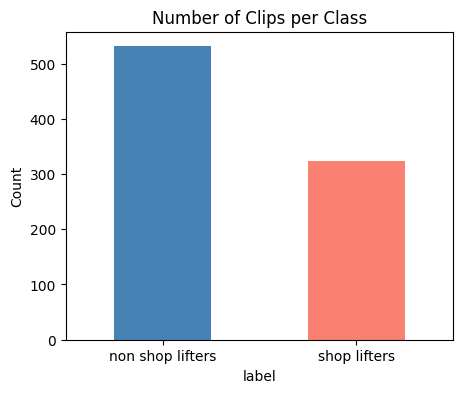

label
non shop lifters    531
shop lifters        324
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(5,4))
meta_df["label"].value_counts().plot(kind="bar", color=["steelblue","salmon"])
plt.title("Number of Clips per Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print(meta_df["label"].value_counts())

# ---- 5. Remove Duplicate Clips (_1 suffix)

In [14]:
import re

def is_duplicate_suffix(filename):
    """
    Flags filenames ending in '_1' before the extension, e.g.
    shop_lifter_n_13_1.mp4 -> duplicate of shop_lifter_n_13.mp4
    """
    name_no_ext = os.path.splitext(filename)[0]
    return bool(re.search(r"_1$", name_no_ext))

# Identify duplicates
meta_df["is_duplicate"] = meta_df["filename"].apply(is_duplicate_suffix)

dup_counts = meta_df.groupby(["label", "is_duplicate"]).size()
print("Duplicate counts by label:")
print(dup_counts)

# Sanity check: confirm duplicates only exist in non shop lifters
dup_in_shoplifters = meta_df[(meta_df["label"] == "shop lifters") & (meta_df["is_duplicate"])]
print(f"\nDuplicates found in 'shop lifters' class: {len(dup_in_shoplifters)}")

Duplicate counts by label:
label             is_duplicate
non shop lifters  False           311
                  True            220
shop lifters      False           319
                  True              5
dtype: int64

Duplicates found in 'shop lifters' class: 5


In [15]:
# Drop duplicates, keep only original clips
meta_df_clean = meta_df[~meta_df["is_duplicate"]].drop(columns=["is_duplicate"]).reset_index(drop=True)

print("Class distribution AFTER removing duplicates:")
print(meta_df_clean["label"].value_counts())

print(f"\nTotal videos before: {len(meta_df)}")
print(f"Total videos after:  {len(meta_df_clean)}")

Class distribution AFTER removing duplicates:
label
shop lifters        319
non shop lifters    311
Name: count, dtype: int64

Total videos before: 855
Total videos after:  630


In [16]:
# Overwrite meta_df with the cleaned version for all downstream blocks
meta_df = meta_df_clean.copy()
meta_df.to_csv("video_metadata_clean.csv", index=False)
meta_df["label"].value_counts()

label
shop lifters        319
non shop lifters    311
Name: count, dtype: int64

# ---- 6. Clip duration distribution ----

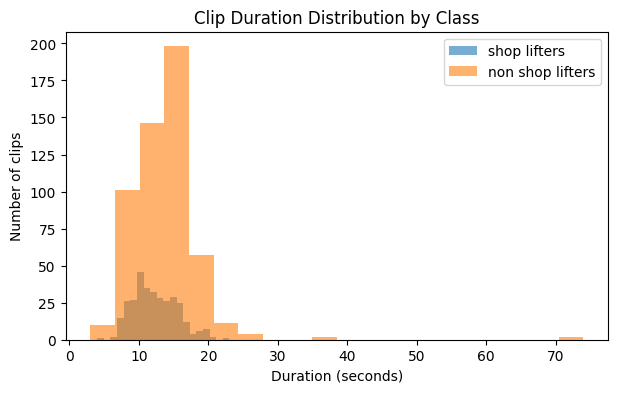

                  count       mean       std  min   25%   50%   75%        max
label                                                                         
non shop lifters  531.0  13.925970  5.367815  3.0  11.0  14.0  16.0  74.000000
shop lifters      324.0  12.223968  3.354683  4.0  10.0  12.0  15.0  23.030303


In [6]:
plt.figure(figsize=(7,4))
for label in meta_df["label"].unique():
    subset = meta_df[meta_df["label"] == label]
    plt.hist(subset["duration_sec"], bins=20, alpha=0.6, label=label)
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of clips")
plt.title("Clip Duration Distribution by Class")
plt.legend()
plt.show()

print(meta_df.groupby("label")["duration_sec"].describe())

# ---- 6. Frame count distribution (important for sampling strategy later) ----

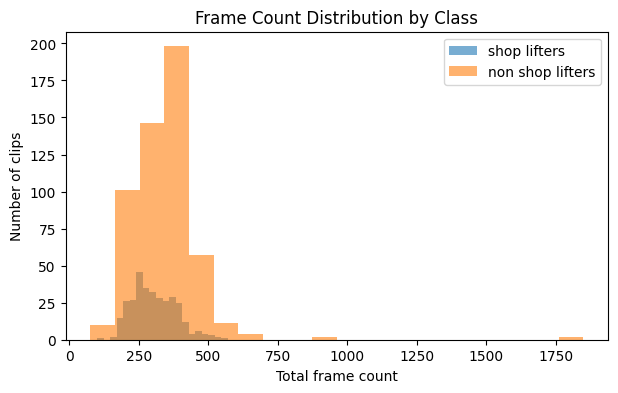

                  count        mean         std    min    25%    50%    75%  \
label                                                                         
non shop lifters  531.0  347.783427  134.202129   75.0  275.0  348.0  400.0   
shop lifters      324.0  304.601852   83.470572  100.0  248.0  300.0  372.0   

                     max  
label                     
non shop lifters  1850.0  
shop lifters       570.0  


In [7]:
plt.figure(figsize=(7,4))
for label in meta_df["label"].unique():
    subset = meta_df[meta_df["label"] == label]
    plt.hist(subset["frame_count"], bins=20, alpha=0.6, label=label)
plt.xlabel("Total frame count")
plt.ylabel("Number of clips")
plt.title("Frame Count Distribution by Class")
plt.legend()
plt.show()

print(meta_df.groupby("label")["frame_count"].describe())

# ---- 7. Frame resolution check ----

In [8]:
print("Unique resolutions (width x height):")
print(meta_df.groupby(["width","height"]).size().sort_values(ascending=False))

Unique resolutions (width x height):
width  height
704    576       855
dtype: int64


# ---- 8. Sample a few frames visually from each class ----

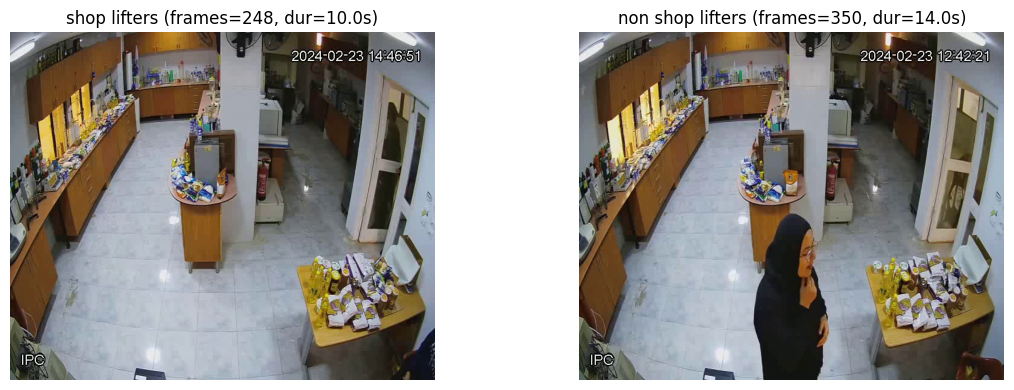

In [9]:
def show_sample_frame(filepath, title=""):
    cap = cv2.VideoCapture(filepath)
    ret, frame = cap.read()
    cap.release()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.title(title)
        plt.axis("off")

plt.figure(figsize=(12,4))
for i, label in enumerate(meta_df["label"].unique()):
    sample_row = meta_df[meta_df["label"] == label].iloc[0]
    plt.subplot(1, 2, i+1)
    show_sample_frame(
        os.path.join(CLASS_DIRS[label], sample_row["filename"]),
        title=f"{label} (frames={sample_row['frame_count']}, dur={sample_row['duration_sec']:.1f}s)"
    )
plt.tight_layout()
plt.show()

## 9. Outlier Inspection

In [10]:
# 1. Flag statistical outliers using IQR per class
def flag_outliers(df, col):
    outlier_rows = []
    for label in df["label"].unique():
        subset = df[df["label"] == label]
        Q1, Q3 = subset[col].quantile(0.25), subset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        out = subset[(subset[col] < lower) | (subset[col] > upper)]
        outlier_rows.append(out)
    return pd.concat(outlier_rows)

dur_outliers = flag_outliers(meta_df, "duration_sec")
frame_outliers = flag_outliers(meta_df, "frame_count")

print(f"Duration outliers: {len(dur_outliers)}")
print(dur_outliers[["filename","label","frame_count","fps","duration_sec"]].sort_values("duration_sec", ascending=False))

print(f"\nFrame count outliers: {len(frame_outliers)}")
print(frame_outliers[["filename","label","frame_count","fps","duration_sec"]].sort_values("frame_count", ascending=False))

Duration outliers: 12
                    filename             label  frame_count    fps  \
401     shop_lifter_n_13.mp4  non shop lifters         1850  25.00   
596   shop_lifter_n_13_1.mp4  non shop lifters         1850  25.00   
739   shop_lifter_n_44_1.mp4  non shop lifters          900  25.00   
345     shop_lifter_n_44.mp4  non shop lifters          900  25.00   
770  shop_lifter_n_206_1.mp4  non shop lifters          650  25.00   
626    shop_lifter_n_206.mp4  non shop lifters          650  25.00   
800   shop_lifter_n_66_1.mp4  non shop lifters          625  25.00   
484     shop_lifter_n_66.mp4  non shop lifters          625  25.00   
335       videppppsss_37.mp4  non shop lifters          596  24.83   
18        shop_lifter_39.mp4      shop lifters          570  24.75   
716  shop_lifter_n_215_1.mp4  non shop lifters           75  25.00   
840    shop_lifter_n_215.mp4  non shop lifters           75  25.00   

     duration_sec  
401     74.000000  
596     74.000000  
739    

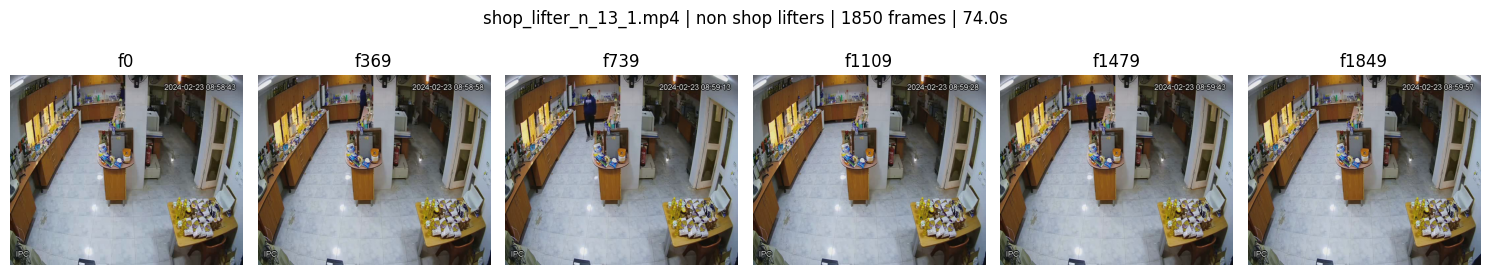

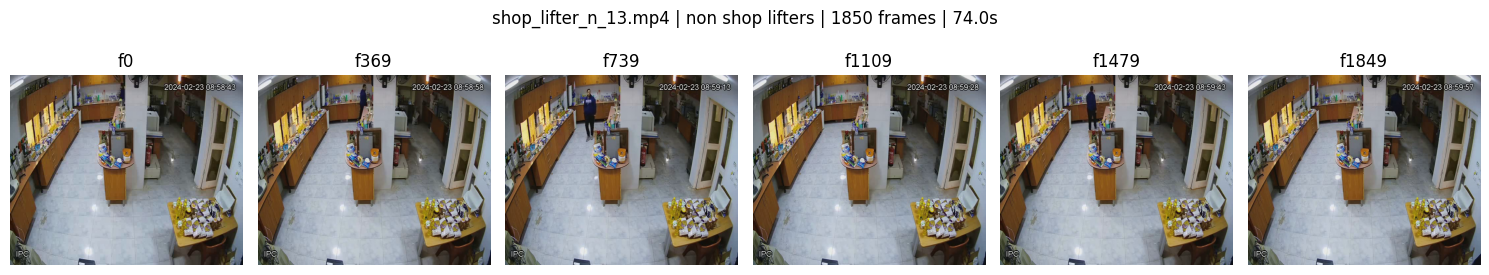

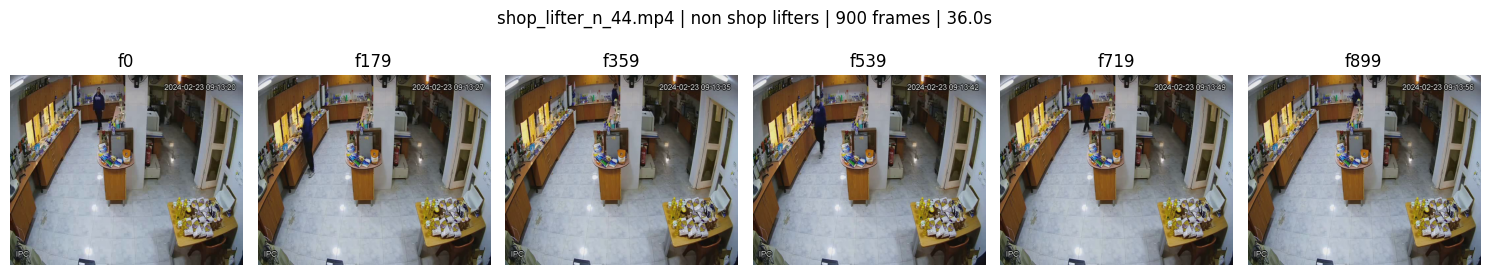

In [11]:
# 2. Visually inspect the most extreme outlier(s)
def show_clip_frames(filepath, n=6, title=""):
    cap = cv2.VideoCapture(filepath)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, total-1, n).astype(int)
    
    plt.figure(figsize=(15,3))
    for i, idx in enumerate(idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.subplot(1, n, i+1)
            plt.imshow(frame_rgb)
            plt.title(f"f{idx}")
            plt.axis("off")
    cap.release()
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Inspect top 3 most extreme by frame_count
top_outliers = meta_df.sort_values("frame_count", ascending=False).head(3)
for _, row in top_outliers.iterrows():
    fp = os.path.join(CLASS_DIRS[row["label"]], row["filename"])
    show_clip_frames(fp, n=6, title=f"{row['filename']} | {row['label']} | {row['frame_count']} frames | {row['duration_sec']:.1f}s")

In [12]:
# 3. Check for near-duplicate / corrupted / zero-frame videos
zero_frame = meta_df[meta_df["frame_count"] <= 1]
print(f"Zero/near-zero frame videos: {len(zero_frame)}")
print(zero_frame)

low_fps = meta_df[meta_df["fps"] <= 1]
print(f"\nSuspiciously low fps videos: {len(low_fps)}")
print(low_fps)

Zero/near-zero frame videos: 0
Empty DataFrame
Columns: [frame_count, fps, width, height, duration_sec, filename, label]
Index: []

Suspiciously low fps videos: 0
Empty DataFrame
Columns: [frame_count, fps, width, height, duration_sec, filename, label]
Index: []


# BLOCK 2: Frame Sampling Strategy

In [17]:
import cv2
import numpy as np

def compute_motion_scores(frames_gray):
    """
    Compute motion score for each frame index (except the first) as
    mean absolute pixel difference from the previous frame.
    Returns array of length len(frames_gray), first entry = 0.
    """
    scores = [0.0]
    for i in range(1, len(frames_gray)):
        diff = cv2.absdiff(frames_gray[i], frames_gray[i-1])
        scores.append(float(np.mean(diff)))
    return np.array(scores)


def sample_frame_indices(total_frames, T, motion_scores=None, uniform_ratio=0.5):
    """
    Hybrid frame sampling: part uniform coverage, part motion-biased.
    
    Args:
        total_frames: total number of frames in the video
        T: target number of frames to sample
        motion_scores: optional array (len=total_frames) of per-frame motion scores.
                        If None, falls back to pure uniform sampling.
        uniform_ratio: fraction of T reserved for uniform coverage (0-1)
    
    Returns:
        sorted list of T frame indices (chronological order)
    """
    if total_frames <= T:
        # short clip: just take every frame, pad by repeating last frame
        idxs = list(range(total_frames))
        while len(idxs) < T:
            idxs.append(total_frames - 1)
        return sorted(idxs)

    if motion_scores is None:
        # pure uniform fallback
        skip = total_frames // T
        idxs = [min(i * skip, total_frames - 1) for i in range(T)]
        return sorted(idxs)

    # --- Hybrid: uniform part + motion-biased part ---
    n_uniform = max(1, int(T * uniform_ratio))
    n_motion = T - n_uniform

    # 1. Uniform indices spanning full duration
    skip = total_frames // n_uniform
    uniform_idxs = [min(i * skip, total_frames - 1) for i in range(n_uniform)]

    # 2. Motion-biased indices: pick top motion-score frames,
    #    excluding ones already picked, with simple non-max suppression
    #    to avoid clustering all picks in one motion spike
    remaining_scores = motion_scores.copy()
    remaining_scores[uniform_idxs] = -1  # exclude already-selected

    motion_idxs = []
    min_gap = max(1, total_frames // (n_motion * 3))  # spacing to avoid clustering
    sorted_by_motion = np.argsort(remaining_scores)[::-1]

    for idx in sorted_by_motion:
        if remaining_scores[idx] < 0:
            continue
        if all(abs(idx - existing) >= min_gap for existing in motion_idxs):
            motion_idxs.append(int(idx))
        if len(motion_idxs) >= n_motion:
            break

    # fallback if not enough motion frames found (e.g. very short/static clip)
    while len(motion_idxs) < n_motion:
        candidate = np.random.randint(0, total_frames)
        if candidate not in motion_idxs and candidate not in uniform_idxs:
            motion_idxs.append(candidate)

    all_idxs = sorted(set(uniform_idxs + motion_idxs))
    
    # in rare case of overlap reducing count below T, top up uniformly
    while len(all_idxs) < T:
        candidate = np.random.randint(0, total_frames)
        if candidate not in all_idxs:
            all_idxs.append(candidate)
    all_idxs = sorted(all_idxs)[:T]

    return all_idxs

In [18]:
# Helper: read all frames (grayscale, downscaled) for motion scoring
def get_grayscale_frames(filepath, resize_to=(160, 120)):
    """
    Reads all frames from a video, converts to grayscale, resizes small
    for fast motion score computation.
    """
    cap = cv2.VideoCapture(filepath)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, resize_to)
        frames.append(gray)
    cap.release()
    return frames

Video: shop_lifter_75.mp4 | total_frames=248
Selected indices (16): [0, 1, 12, 31, 60, 62, 72, 93, 108, 120, 124, 155, 168, 186, 216, 217]


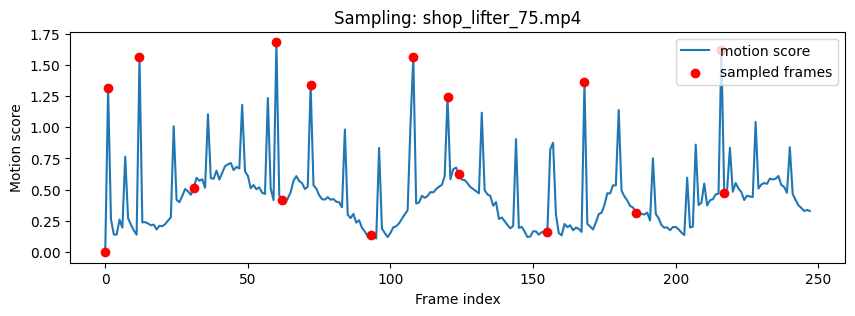

In [19]:
# Test the sampling strategy on a few clips
T = 16

test_row = meta_df.iloc[0]
fp = os.path.join(CLASS_DIRS[test_row["label"]], test_row["filename"])

gray_frames = get_grayscale_frames(fp)
motion_scores = compute_motion_scores(gray_frames)
selected_idxs = sample_frame_indices(len(gray_frames), T, motion_scores)

print(f"Video: {test_row['filename']} | total_frames={len(gray_frames)}")
print(f"Selected indices ({len(selected_idxs)}): {selected_idxs}")

# Visualize motion score curve with selected frames marked
plt.figure(figsize=(10,3))
plt.plot(motion_scores, label="motion score")
plt.scatter(selected_idxs, motion_scores[selected_idxs], color="red", zorder=5, label="sampled frames")
plt.xlabel("Frame index")
plt.ylabel("Motion score")
plt.title(f"Sampling: {test_row['filename']}")
plt.legend()
plt.show()

# BLOCK 3: PyTorch Dataset Class

In [20]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
import random
from PIL import Image

class ShopliftingDataset(Dataset):
    def __init__(self, df, class_dirs, T=16, frame_size=112, train=True):
        """
        df: metadata dataframe with 'filename' and 'label' columns
        class_dirs: dict mapping label -> folder path
        T: number of frames to sample per clip
        frame_size: output spatial size (square) after crop
        train: if True, apply random augmentation; if False, use center crop only
        """
        self.df = df.reset_index(drop=True)
        self.class_dirs = class_dirs
        self.T = T
        self.frame_size = frame_size
        self.train = train
        self.label_map = {"non shop lifters": 0, "shop lifters": 1}

    def __len__(self):
        return len(self.df)

    def _get_grayscale_frames(self, filepath, resize_to=(160, 120)):
        cap = cv2.VideoCapture(filepath)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, resize_to)
            frames.append(gray)
        cap.release()
        return frames

    def _read_rgb_frame(self, cap, idx):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            return None
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return Image.fromarray(frame_rgb)

    def _sample_clip_augmentation_params(self, orig_size):
        """
        Sample ONE set of random augmentation params per clip,
        to be applied identically to every frame.
        """
        w, h = orig_size
        params = {}

        # random flip
        params["flip"] = random.random() < 0.5 if self.train else False

        # random crop box (or center crop for eval)
        crop_size = min(w, h)
        if self.train:
            max_x = w - crop_size
            max_y = h - crop_size
            params["crop_x"] = random.randint(0, max_x) if max_x > 0 else 0
            params["crop_y"] = random.randint(0, max_y) if max_y > 0 else 0
        else:
            params["crop_x"] = (w - crop_size) // 2
            params["crop_y"] = (h - crop_size) // 2
        params["crop_size"] = crop_size

        # color jitter factors (sampled once, applied to all frames)
        if self.train:
            params["brightness"] = random.uniform(0.8, 1.2)
            params["contrast"] = random.uniform(0.8, 1.2)
            params["saturation"] = random.uniform(0.8, 1.2)
        else:
            params["brightness"] = 1.0
            params["contrast"] = 1.0
            params["saturation"] = 1.0

        return params

    def _apply_clip_augmentation(self, img, params):
        # crop
        img = TF.crop(img, params["crop_y"], params["crop_x"],
                       params["crop_size"], params["crop_size"])
        # resize to target
        img = TF.resize(img, [self.frame_size, self.frame_size])
        # flip
        if params["flip"]:
            img = TF.hflip(img)
        # color jitter (same factors every frame)
        img = TF.adjust_brightness(img, params["brightness"])
        img = TF.adjust_contrast(img, params["contrast"])
        img = TF.adjust_saturation(img, params["saturation"])
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label_str = row["label"]
        filepath = os.path.join(self.class_dirs[label_str], row["filename"])
        label = self.label_map[label_str]

        # 1. Motion-aware sampling (reuses functions from Block 2)
        gray_frames = self._get_grayscale_frames(filepath)
        total_frames = len(gray_frames)
        motion_scores = compute_motion_scores(gray_frames)
        selected_idxs = sample_frame_indices(total_frames, self.T, motion_scores)

        # 2. Open video once for RGB frame reads
        cap = cv2.VideoCapture(filepath)
        first_frame = self._read_rgb_frame(cap, selected_idxs[0])
        orig_size = first_frame.size  # (w, h)

        # 3. Sample ONE augmentation param set for the whole clip
        aug_params = self._sample_clip_augmentation_params(orig_size)

        # 4. Read + augment all T frames consistently
        frames_tensor = []
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # reset just in case
        for f_idx in selected_idxs:
            img = self._read_rgb_frame(cap, f_idx)
            if img is None:
                img = frames_tensor[-1] if frames_tensor else Image.new("RGB", orig_size)
                img = TF.to_pil_image(img) if isinstance(img, torch.Tensor) else img
            img = self._apply_clip_augmentation(img, aug_params)
            img_tensor = TF.to_tensor(img)  # (C, H, W), values in [0,1]
            frames_tensor.append(img_tensor)
        cap.release()

        clip_tensor = torch.stack(frames_tensor, dim=0)  # (T, C, H, W)

        # 5. Normalize (ImageNet stats are fine as generic normalization even from-scratch)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        clip_tensor = (clip_tensor - mean) / std

        return clip_tensor, label

In [21]:
# Sanity check the Dataset class 
from torch.utils.data import DataLoader

train_ds = ShopliftingDataset(meta_df, CLASS_DIRS, T=16, frame_size=112, train=True)
clip, label = train_ds[0]
print("Clip tensor shape:", clip.shape)   # (16, 3, 112, 112)
print("Label:", label)

# Check a batch via DataLoader
loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
batch_clips, batch_labels = next(iter(loader))
print("Batch shape:", batch_clips.shape)  # (4, 16, 3, 112, 112)
print("Batch labels:", batch_labels)

Clip tensor shape: torch.Size([16, 3, 112, 112])
Label: 1
Batch shape: torch.Size([4, 16, 3, 112, 112])
Batch labels: tensor([0, 1, 1, 1])


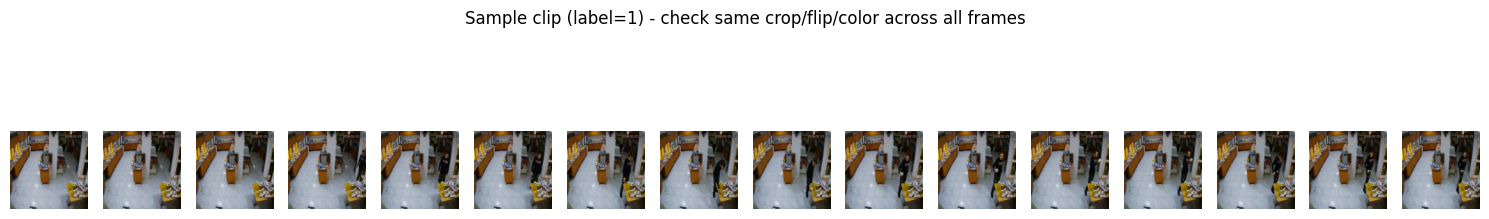

In [25]:
# Visual check: confirm augmentation is IDENTICAL across frames in a clip
def visualize_clip_tensor(clip_tensor, title=""):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    plt.figure(figsize=(15, 3))
    for i in range(clip_tensor.shape[0]):
        img = clip_tensor[i] * std + mean
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()
        plt.subplot(1, clip_tensor.shape[0], i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig("Sample_clip.png")
    plt.show()

visualize_clip_tensor(clip, title=f"Sample clip (label={label}) - check same crop/flip/color across all frames")

# BLOCK 4: From-Scratch 3D CNN Model

In [26]:
import torch
import torch.nn as nn

class Shoplifting3DCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()

        # Input: (B, C, T, H, W) 
        # we'll permute from (B, T, C, H, W)
        self.features = nn.Sequential(
            # Block 1
            nn.Conv3d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),  # keep T, halve spatial

            # Block 2
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),  # halve T and spatial

            # Block 3
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),

            # Block 4
            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)),  # global pool -> (B, 256, 1, 1, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm3d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x comes in as (B, T, C, H, W) from the Dataset/DataLoader
        x = x.permute(0, 2, 1, 3, 4)  # -> (B, C, T, H, W) for Conv3d
        x = self.features(x)
        x = self.classifier(x)
        return x

In [27]:
# Sanity check: forward pass with a real batch 
model = Shoplifting3DCNN(num_classes=2)

# reuse batch_clips from Block 3's DataLoader check
out = model(batch_clips)
print("Output shape:", out.shape)  # (4, 2)
print("Output logits:\n", out)

# Param count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Output shape: torch.Size([4, 2])
Output logits:
 tensor([[-0.0159, -0.0154],
        [-0.0058, -0.0132],
        [-0.0051, -0.0231],
        [-0.0062, -0.0150]], grad_fn=<AddmmBackward0>)

Total params: 1,198,402
Trainable params: 1,198,402


# BLOCK 5: Train/Val/Test Split

In [28]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve class balance across sets
train_df, temp_df = train_test_split(
    meta_df, test_size=0.3, stratify=meta_df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain distribution:\n", train_df["label"].value_counts())
print("\nVal distribution:\n", val_df["label"].value_counts())
print("\nTest distribution:\n", test_df["label"].value_counts())

Train: 441 | Val: 94 | Test: 95

Train distribution:
 label
shop lifters        223
non shop lifters    218
Name: count, dtype: int64

Val distribution:
 label
shop lifters        48
non shop lifters    46
Name: count, dtype: int64

Test distribution:
 label
shop lifters        48
non shop lifters    47
Name: count, dtype: int64


# BLOCK 6: DataLoaders

In [29]:
train_ds = ShopliftingDataset(train_df, CLASS_DIRS, T=16, frame_size=112, train=True)
val_ds   = ShopliftingDataset(val_df,   CLASS_DIRS, T=16, frame_size=112, train=False)
test_ds  = ShopliftingDataset(test_df,  CLASS_DIRS, T=16, frame_size=112, train=False)

BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 56 | Val batches: 12 | Test batches: 12


# BLOCK 7: Training Setup

In [30]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = Shoplifting3DCNN(num_classes=2).to(device)

# class weights (in case balance isn't perfectly even)
class_counts = train_df["label"].value_counts()
weight_non = 1.0 / class_counts["non shop lifters"]
weight_shop = 1.0 / class_counts["shop lifters"]
class_weights = torch.tensor([weight_non, weight_shop], dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * 2  # normalize

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

Using device: cuda


# BLOCK 8: Train / Eval Loop Functions

In [31]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    torch.set_grad_enabled(is_train)
    for clips, labels in loader:
        clips, labels = clips.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(clips)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * clips.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )
    return avg_loss, acc, precision, recall, f1

# BLOCK 9: Training Loop

In [35]:
NUM_EPOCHS = 5
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_f1 = 0.0
epochs_no_improve = 0
PATIENCE = 2  # stop if val F1 doesn't improve for this many epochs

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_prec, train_rec, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_prec, val_rec, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  -> New best model saved (Val F1: {val_f1:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE} epochs")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1} (best Val F1: {best_val_f1:.4f})")
        break

print(f"\nTraining finished. Best Val F1: {best_val_f1:.4f}")

Epoch 1/5 | Train Loss: 0.6923 Acc: 0.5238 F1: 0.5833 | Val Loss: 0.6899 Acc: 0.5638 F1: 0.6612
  -> New best model saved (Val F1: 0.6612)
Epoch 2/5 | Train Loss: 0.6916 Acc: 0.5193 F1: 0.5411 | Val Loss: 0.6894 Acc: 0.4894 F1: 0.0000
  -> No improvement for 1/2 epochs
Epoch 3/5 | Train Loss: 0.6908 Acc: 0.5601 F1: 0.5245 | Val Loss: 0.6877 Acc: 0.5106 F1: 0.6761
  -> New best model saved (Val F1: 0.6761)
Epoch 4/5 | Train Loss: 0.6905 Acc: 0.5261 F1: 0.4814 | Val Loss: 0.6887 Acc: 0.4894 F1: 0.0000
  -> No improvement for 1/2 epochs
Epoch 5/5 | Train Loss: 0.6854 Acc: 0.6009 F1: 0.6140 | Val Loss: 0.6908 Acc: 0.4894 F1: 0.0000
  -> No improvement for 2/2 epochs

Early stopping triggered at epoch 5 (best Val F1: 0.6761)

Training finished. Best Val F1: 0.6761


# BLOCK 10: Test Set Evaluation

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best checkpoint (based on val F1)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_loss, test_acc, test_prec, test_rec, test_f1 = run_epoch(model, test_loader, criterion, optimizer=None)

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")

FINAL TEST SET RESULTS
Loss:      0.6912
Accuracy:  0.5053
Precision: 0.5053
Recall:    1.0000
F1-score:  0.6713


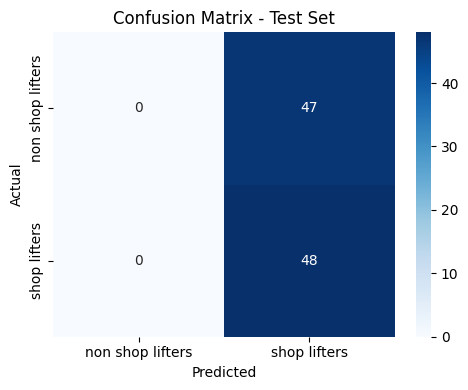


Full Classification Report:
                  precision    recall  f1-score   support

non shop lifters     0.0000    0.0000    0.0000        47
    shop lifters     0.5053    1.0000    0.6713        48

        accuracy                         0.5053        95
       macro avg     0.2526    0.5000    0.3357        95
    weighted avg     0.2553    0.5053    0.3392        95



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
# Detailed predictions for confusion matrix + full classification report
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for clips, labels in test_loader:
        clips = clips.to(device)
        outputs = model(clips)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
label_names = ["non shop lifters", "shop lifters"]

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

print("\nFull Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))

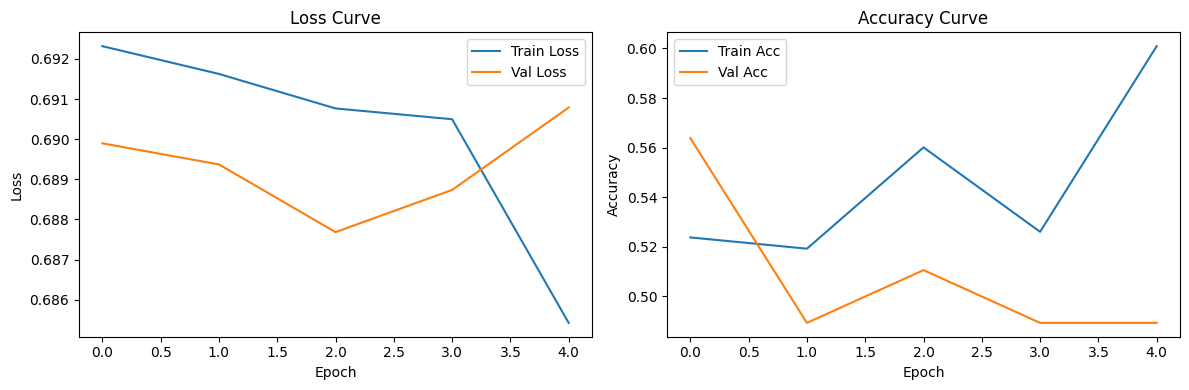

In [38]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()